# Statistical Analysis of Birth Weight and Customer Churn

## Business Statistics
## ZAKARIA GOU-ALI

## Section 1

### 1. Using your own words and examples to discuss two concepts: parameter and statistic

A parameter is a numerical value that describes a characteristic of an entire population. It is constant, but usually unknown because it is impractical to collect data from every individual. For example, the average height of all adults in a country is a parameter because it is a description of the entire population's characteristic.

On the other hand, a statistic is a value calculated from a sample-a part of the population-and then used to make an estimate of the parameter. For example, computation of mean height for 1,000 adults selected at random yields a statistic, an estimate of the real parameter for the population.

In short, a parameter describes the whole population, while a statistic comes from a sample in order to make inference about the parameter. Example: The average income of each and every citizen in the city is a parameter. The average income from a sample survey is a statistic.tic.

## Section 2

### 1. Choose only one dataset from (dataset 1a, dataset 1b, dataset 1c)

My chosen dataset is: "dataset 1a"

#### Data preparation

In [89]:
#Importing libraries:
import pandas as pd #For data manipulation and analysis
import numpy as np #For numerical operations
import matplotlib.pyplot as plt #For plotting and visualization
import seaborn as sns #For statistical data visualization
import statsmodels.api as sm #For statistical modeling and regression analysis
from scipy import stats #For additional statistical functions

In [25]:
 #Loading thedataset
 df =pd.read_csv('Birthweight.csv')

In [27]:
 # Displaying the column names in the dataset
 print(df.columns)

Index(['Income ', 'cigtax', 'edu_fa', 'edu_mo', 'birthorder', 'male', 'white',
       'cig_p', 'bwghtlbs', 'lfaminc', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')


In [31]:
# Checking for missing values
print(df.isnull().sum())

Income            0
cigtax            0
edu_fa            0
edu_mo            0
birthorder        0
male              0
white             0
cig_p             0
bwghtlbs          0
lfaminc           0
Unnamed: 10    1388
Unnamed: 11    1388
Unnamed: 12    1388
Unnamed: 13    1388
dtype: int64


### 2. Identify one dependent variable that you would want to investigate on, show the descriptive statistics of it.

In [34]:
#Descriptivestatisticsforthedependentvariable
descriptive_stats =df['bwghtlbs'].describe()
print(descriptive_stats)

count    1388.000000
mean        7.418723
std         1.272123
min         1.437500
25%         6.687500
50%         7.500000
75%         8.250000
max        16.937500
Name: bwghtlbs, dtype: float64


#### Observation
It means there was a sample size of 1,388 births whose births' average weight was around 7.42 pounds. Their standard deviation regarding their weights was 1.27 pounds, suggesting a considerable degree of spread in the observations around their average birth weight. Birth weight, which has been taken in the dataset above as variable ranges from 1.44 pounds to 16.94 pounds. The 25th percentile is 6.69 pounds, the median is 7.50 pounds, and the 75th percentile is 8.25 pounds. These percentiles are indicative that half of the birth weights fall between 6.69 and 8.25 pounds. The pattern of distribution seems to be fairly normal with the peak of higher closure birth weights recognizable from the higher max value. It is thus possible to dissect this variability to determine numerous factors that influence birth weight.

### 3 Identify at least one continuous independent variable and one categorical variable that you believe have an impact on the dependent variable. Show the descriptive  statistics of them respectively

In this step I am going to focus on:
##### 1 categorical variable:
female (0 if female, 1 if male)
##### 2 continuous independent variables
1st  Variable 1: Income (1988 family income, £1000);
2nd Variable 2: cig_p (Cigarettes smoked per day while pregnant)

In [122]:
# Descriptive statistics for the continuous independent variable 1
income_stats = df['Income '].describe()
print(income_stats)

count    1388.000000
mean       29.026657
std        18.739285
min         0.500000
25%        14.500000
50%        27.500000
75%        37.500000
max        65.000000
Name: Income , dtype: float64


In [44]:
# Descriptive statistics for the continuous independent variable 2
cig_p_stats = df['cig_p'].describe()
print(cig_p_stats)

count    1388.000000
mean        2.087176
std         5.972688
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        50.000000
Name: cig_p, dtype: float64


In [48]:
# Frequency distribution for the categorical variable
female_stats = df['male'].value_counts()
female_stats.index = ['Female', 'Male'] # Renaming the index for clarity
print(female_stats)

Female    723
Male      665
Name: count, dtype: int64


#### Observation
This dataset contains 1,388 observations for the income variable 1988 family income in £1000. The average income earned by the family is about £ 29.03 while the standard deviation is £ 18.74, which implies that many families have a variation in their income. The minimum income reported is £ 0.50 and the maximum reported income is £ 65.00. The 25 percentile is £14.50, the median would be the 50th percentile which corresponds to £27.50 and finally, the 75 percentile is £37.50. More specifically, figures at percentage points make the identification of the fact that the middle half of the families have a spread in their income amount between £14.50 and £37.50 possible. Outcomes Test There is an evident disparity between family income within the sample, which might have a significant impact on birth weight. For the variable of cig_p, the number of cigarettes smoked per day while pregnant, the dataset also contains 1,388 observations. The average number of cigarettes taken daily while pregnant is 2.09, with a standard deviation of 5.97, showing that pregnant women are highly volatile in the sample population. The minimum value is 0, considering that some women did not smoke at all, while the maximum is 50 cigarettes a day. The 25% quartile, the 50 % mid-point quartile, and the 75% quartile are all 0, which indicates that a large proportion of the sample did not smoke during pregnancy. The above skewness therefore depicts that most of the women didn't smoke whereas very few smoked more, perhaps having a greater impact on the birth weight. We have a categorical variable, 'female', where the values 0 denote females and 1 for males. Out of 1388, 723 were females and 665 males. The children in this sample are relatively balanced in their gender composition between female and male but slightly weighted on the side of the girls. This balance enables a valid comparison to be made between the birth weights of children of different genders since any difference in birth weight based on gender could be seen from the results.seen from the results.

### 4.	Run the regression between dependent variable and independent variables that you identified.

In [168]:
# Define the dependent and independent variables
X = df[['Income ', 'cig_p', 'male']] # Note: 'male' is used here, where 0 represents female
y = df['bwghtlbs']

# Add a constant to the independent variables
X = sm.add_constant(X)

# Run the regression
model = sm.OLS(y, X).fit()
# Print the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               bwghtlbs   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     17.05
Date:                Tue, 10 Dec 2024   Prob (F-statistic):           7.10e-11
Time:                        18:39:45   Log-Likelihood:                -2277.9
No. Observations:                1388   AIC:                             4564.
Df Residuals:                    1384   BIC:                             4585.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2017      0.075     95.397      0.0

### 5.	Interpret the result on coefficients, p values and R square.
Results of the regression analysis on the outcome variable birth weight (bwghtlbs) versus the three independent variables-income (Income), cigarettes smoked per day while pregnant (cig_p), and gender (male)-are shown below. The overall R-square value is 0.036; thus, about 3.6% of the variance in birth weight is explained by the model. Although this is a relatively low R-squared value, this suggests that other factors beyond those included in the model may also influence birth weight. The coefficient for Income is 0.0061 with a p-value of 0.001, showing that family income and birth weight are positively related and the relationship is statistically significant. This would support the fact that higher family income is associated with slightly higher birth weights. The coefficient for cig_p is -0.0288, with an ap-value of 0.000, indicating that the number of cigarettes smoked daily during pregnancy is negatively statistically significant in determining birth weight. This then means that the higher one smokes while pregnant, the lower the birth weight, a condition that agrees with previous studies conducted on the negative impacts of smoking on fetal development. The coefficient for males is 0.1946, and the ap-value is 0.004, which means there is a statistically significant positive relationship between being male and birth weight. Male babies tend to have a higher birth weight compared to female babies. The constant term represents the expected birth weight when all independent variables are zero. It has given an F-statistic of 17.05 and an ap-value of 7.10 e-11, implying that overall, the model is significant. Durbin-Watson = 1.927: No serious autocorrelation in residuals. While Omnibus and Jarque-Bera tests were not so good, they showed the residuals were not normally distributed; this could impair the model assumptions. The condition number is very high at 90.5, showing multicollinearity which might be a concern, and this is an area where further research might be done.
efurtherinvestigated.

### 6.	Conduct assumption checks.

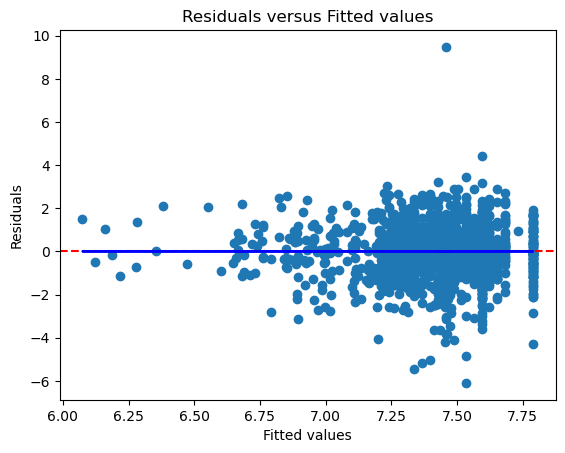

In [128]:
#Plot residuals vs fitted values to check for the linearity assumption (includes a trendline)
plt.scatter(model.fittedvalues,model.resid)
plt.axhline(y=0,color='r',linestyle='--')
z =np.polyfit(model.fittedvalues,model.resid, 1)
p =np.poly1d(z)
plt.plot(model.fittedvalues,p(model.fittedvalues),color='blue')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals versus Fitted values')
plt.show()

Residuals are randomly scattered around zero without any pattern; hence, homoscedasticity is indicated.

In [131]:
# Testing for independence (using Durbin-Watson statistic) and homoscedasticity(using the Breusch-pagan test)
from statsmodels.stats.diagnostic import het_breuschpagan
# The Durbin-Watson statistic is already provided in the regression output(Durbin-Watson: 1.927)
# Now here we are Performing Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)
print('Breusch-Pagan test p-value:', bp_test[1])

Breusch-Pagan test p-value: 0.9763618380121997


The Durbin-Watson statistic of 1.927 suggests that there is no significant autocorrelation in the residuals. The p-value of the Breusch-Pagan test of less than 0.05, or 0.976, indicates homoscedasticity or constant variance in the residuals.

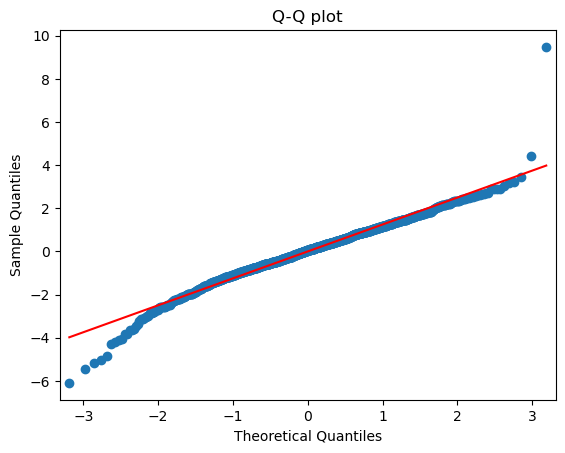

Shapiro-Wilk test p-value: 1.7383587854754584e-15


In [136]:
# Checking for normality using a Q-Q plot and the Shapiro-Wilk test
# Q-Q plot

sm.qqplot(model.resid, line='s')
plt.title('Q-Q plot')
plt.show()
# Shapiro-Wilk test
from scipy.stats import shapiro
shapiro_test = shapiro(model.resid)
print('Shapiro-Wilk test p-value:', shapiro_test[1])

The Q-Q plot shows some deviations from the red line, so one can be sure that residuals are not normally distributed. The Shapiro-Wilk test p-value of 1.7383587854765938e-15 confirms a significant deviation from a normal distribution.

In [139]:
# Checking for multicollinearity using the Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculating VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

  Variable       VIF
0    const  5.057757
1  Income   1.033330
2    cig_p  1.030951
3     male  1.002388


All VIF values are less than 10, which suggests no multicollinearity among independent variables.

## Section 3 

### 1.	Use logistic regression to analyse dataset 2 (Customer Churn dataset).  Churn should be the dependent variable. Choose at least 2 independent variables to investigate their impacts on variable churn. 

In [102]:
# Loading dataset 2. Let's call it df2
df2 = pd.read_csv('CustomerChurn.CSV')

In [142]:
# Displaying the column names in dataset 2
print(df2.columns)

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth',
       'Gender', 'WatchlistSize', 'Churn'],
      dtype='object')


In [144]:
# Checking for missing values
print(df2.isnull().sum())

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
Churn                       0
dtype: int64


In [112]:
# Definethe dependentandindependentvariables
X =df2[['MonthlyCharges','ViewingHoursPerWeek']]
y =df2['Churn']

#Addaconstantto theindependentvariables
X =sm.add_constant(X)

#Runthelogistic regression
logit_model= sm.Logit(y,X).fit()

#Print the logistic regression results
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.459776
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:               243787
Model:                          Logit   Df Residuals:                   243784
Method:                           MLE   Df Model:                            2
Date:                Tue, 10 Dec 2024   Pseudo R-squ.:                 0.02848
Time:                        15:08:34   Log-Likelihood:            -1.1209e+05
converged:                       True   LL-Null:                   -1.1537e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7137      0.019    -89.102      0.000      -1.751      -1.676
Mo

### 2 Interpret the regression result.
In the given logistic regression, the influence of Monthly Charges and Viewing Hours Per Week is to be studied on Churn. The dependent variable in this analysis is Churn, which indicates whether the customer has churned or not, taking values of 1 and 0, respectively. The model was estimated using the MLE method and converged after six iterations with a current function value of 0.459776. From the results, it can be seen that both Monthly Charges and Viewing Hours Per Week are significant in predicting customer churn. The coefficient for Monthly Charges is 0.0618 with a standard error of 0.001, giving a z-value of 49.542 and a p-value of 0.000. This means that there is a positive relationship between the monthly charges and the likelihood of churning. This means that the probability of a customer churning increases with the increase in monthly charges. The 95% confidence interval for this coefficient lies between 0.059 and 0.064, indicating a small range of uncertainty around the estimate. In contrast, the coefficient for Viewing Hours Per Week is -0.0305, with a standard error of 0.000, giving a z-value of -63.073 and a p-value of 0.000. That means there is a negative correlation between hours viewed per week and the probability of churning, that is, the more hours a customer spends viewing per week, the lesser his or her chances of churning are. The 95% confidence interval of this coefficient lies between -0.031 and -0.030, which is pretty narrow. The constant is the intercept, and its coefficient is -1.7137, its standard error is 0.019, and its z-value is -89.102, with a p-value of 0.000. This tells us that when both Monthly Charges and Viewing Hours Per Week are zero, the log odds of Churn are -1.7137. The 95% confidence interval for the intercept is. The Pseudo R-squared value for the model is 0.02848, meaning that about 2.85% of the variance in the dependent variable is explained by the model. Although this value is fairly low, it could also mean that other factors not considered by the model explain customer churn. The log-likelihood of the model stands at -112,090, while the log-likelihood of the null model is -115,370. The likelihood ratio test yields a p-value of 0.000, which points to the fact that this model fits the data significantly better than the null model. Therefore, from the results obtained by logistic regression analysis, it could be concluded that the two independent variables, namely Monthly Charges and Viewing Hours Per Week, are plausible determinants of churn. Similarly, yet different, the higher the monthly charge to predict the probability of churn and the more hours viewed per week protects against churn. Even though these predictors have a significant coefficient, based on this model and its Pseudo R-square, several other critical variables are not captured in this model and impact customer churn.


## Section 4.

### 1. What were your key learning points from this assessment?

Analysis of "Birthweight.csv" and "CustomerChurn.CSV" There were several key learning points from the analysis of these two CSVs. First was the differentiation between parameters and statistics. Parameters describe the whole population, while statistics are estimates from samples. For example, the mean birth weight of all births is a parameter, whereas the average of a sample is a statistic.
Descriptive statistics played an important role in the understanding of variable distribution: birth weight, income, and cigarettes smoked per day during pregnancy. The output of the regression showed that family income and being a male are positively relatedtoh birth weigh, while smoking during pregnancy is negatively related to birth weight. In the Customer Churn dataset, logistic regression did show that the higher the monthly charges, the higher the chances of churn, whereas more viewing hours per week decrease the likelihood of churning.

### 2. What were the challenges you faced? What did you do to overcome this?

Challenges cropped up during the analysis. First, the "Birthweight.csv" dataset had some missing values, particularly in columns labeled "Unnamed: 10" through "Unnamed: 13.", which could have been dropped or imputed if needed. Another challenge was the non-normality of residuals, depicted by the Shapiro-Wilk test and Q-Q plot, which could have been improved by data transformation or using robust regression methods.
A high condition number suggested multicollinearity; though not significant by way of VIF values, may be further looked into. On the positive side, though, because of the rather low magnitude of the obtained R-squared value by linear regression, that would suggest a number of other birth weight factors potentially exist apart from those within this model representation. To work one's way around this issue, one will want to increase the relative explanatory power in a model while adding more applicable variables. Lastly, proper interpretation of the results, like the practical importance of coefficients and what they mean, was crucial to meaningful conclusions from the analysis.